In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [2]:
#Defining project root
import sys
from pathlib import Path
# Make sure we can import config.py from project root

# One folder up from current notebook location
project_root = Path.cwd().parent.parent.resolve()

# Add subdirectories to path
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'config'))
print(f"Project root: {project_root}")
import config

Project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [3]:
# unite all dataframes into one
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditions_with_digit_span.csv")

# df_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
# df_im_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_w_gpt_semantic_tags.csv")
# df_delay_mem = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09032026_pilot_2_delayed_memory_digit-span/nlp_analysis/ppt_w_gpt_semantic_tags.csv")

In [8]:

df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'condition',
       'clip_cosine_distance', 'vgg_fc7_distance', 'clip_vis_text_similarity',
       'token_num', 'gt_order'],
      dtype='object')

In [29]:
df_perc = df[df['condition'] == 'perception']
df_im_mem = df[df['condition'] == 'immediate memory']
df_delay_mem = df[df['condition'] == 'delayed memory']


In [39]:
df_delay_mem

,uid,gt,session,attempt,prompt,gen,subjective_score,prompt_latency_secs,generating_latency_secs,rating_latency_secs,...,camera_aspects,optical_effects,subjective_detail,condition,clip_cosine_distance,vgg_fc7_distance,clip_vis_text_similarity,token_num,gt_order,obj_count
180,9o7z7o4e1772730936282,living_room_h.jpg,1,1,A modern living room with a blue sectional cou...,9o7z7o4e1772730936282_session01_attempt01.png,55.0,71.206,19.837,25.563,...,[],[],[],delayed memory,0.145231,0.467565,0.322307,65.0,living_room_h.jpg,8
181,9o7z7o4e1772730936282,living_room_h.jpg,1,2,A modern living room with a blue sectional cou...,9o7z7o4e1772730936282_session01_attempt02.png,69.0,23.790,19.114,25.113,...,[],[],[],delayed memory,0.207542,0.508219,0.325768,74.0,living_room_h.jpg,8
182,9o7z7o4e1772730936282,living_room_h.jpg,1,3,A modern living room with a blue sectional cou...,9o7z7o4e1772730936282_session01_attempt03.png,68.0,6.793,18.883,6.287,...,[],[],[],delayed memory,0.176530,0.457853,0.332169,74.0,living_room_h.jpg,8
183,9o7z7o4e1772730936282,conference_room_h.jpg,2,1,"A tan colored table in the shape of L, sits in...",9o7z7o4e1772730936282_session02_attempt01.png,63.0,71.179,21.216,29.829,...,[],[],[],delayed memory,0.194892,0.378196,0.302044,56.0,living_room_h.jpg,7
184,9o7z7o4e1772730936282,conference_room_h.jpg,2,2,"A tan colored table in the shape of L, sits in...",9o7z7o4e1772730936282_session02_attempt02.png,70.0,4.777,17.589,21.713,...,[],[],[],delayed memory,0.122830,0.516917,0.327435,57.0,living_room_h.jpg,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,puqz4woy1773084496016,conference_room_h.jpg,4,2,Create a image of a office room during the day...,puqz4woy1773084496016_session04_attempt02.png,56.0,136.560,46.288,19.400,...,[],[],[],delayed memory,0.133747,0.442990,0.343693,123.0,bedroom_l.jpg,10
266,puqz4woy1773084496016,conference_room_h.jpg,4,3,Create a image of a office room during the day...,puqz4woy1773084496016_session04_attempt03.png,77.0,86.789,44.125,12.149,...,[],[],[],delayed memory,0.106166,0.353410,0.346272,147.0,bedroom_l.jpg,11
267,puqz4woy1773084496016,lighthouse_h.jpg,5,1,Create a vinage 2000s image shot on a digital ...,puqz4woy1773084496016_session05_attempt01.png,32.0,148.405,19.389,17.079,...,['shot on a digital cam'],[],['vintage 2000s'],delayed memory,0.194722,0.350708,0.327288,39.0,bedroom_l.jpg,2
268,puqz4woy1773084496016,lighthouse_h.jpg,5,2,Create a vintage 2000s image shot on a digital...,puqz4woy1773084496016_session05_attempt02.png,48.0,86.396,20.352,10.494,...,['shot on a digital cam'],[],['vintage'],delayed memory,0.165883,0.347731,0.378565,67.0,bedroom_l.jpg,3


In [42]:
# 1. Calculate the object count
# We handle cases where 'objects' might be a list or a string representation of a list
def count_objects(x):
    if isinstance(x, list):
        return len(x)
    elif isinstance(x, str):
        try:
            # Assumes string is like "['car', 'tree']"
            return len(eval(x))
        except:
            # Fallback if it's just a comma-separated string
            return len(x.split(',')) if x else 0
    return 0

df['obj_count'] = df['objects'].apply(count_objects)

# 2. Create the Summary Table (5 rows for sessions, 3 columns for attempts)
# This shows the average object count across all participants and conditions
summary_table = df.groupby(['session', 'attempt'])['obj_count'].mean().unstack()
print("Average Object Count by Session and Attempt:")
print(summary_table)


Average Object Count by Session and Attempt:
attempt         1         2         3
session                              
1        6.944444  7.500000  8.222222
2        8.388889  8.777778  9.055556
3        5.833333  6.833333  6.888889
4        7.055556  7.388889  7.888889
5        5.611111  6.111111  5.777778


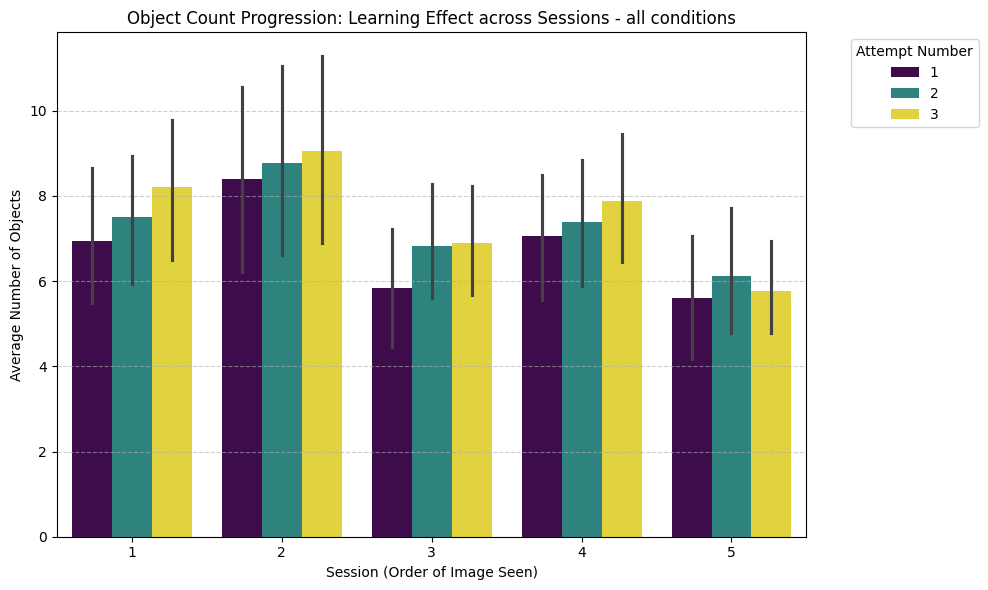

In [44]:
# 3. Create the Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='session', y='obj_count', hue='attempt', palette='viridis')

plt.title('Object Count Progression: Learning Effect across Sessions - all conditions')
plt.xlabel('Session (Order of Image Seen)')
plt.ylabel('Average Number of Objects')
plt.legend(title='Attempt Number', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('object_count_analysis.png')

In [45]:
#deltas analysis:
# 2. Pivot to get Attempts as columns
# This aligns Attempt 1, 2, and 3 for every (uid, session) pair
pivot_df = df.pivot(index=['uid', 'session'], columns='attempt', values='obj_count').reset_index()

In [49]:
pivot_df

attempt,uid,session,1,2,3
0,17t99kvz1765301165519,1,10,10,12
1,17t99kvz1765301165519,2,14,13,14
2,17t99kvz1765301165519,3,9,9,12
3,17t99kvz1765301165519,4,2,4,5
4,17t99kvz1765301165519,5,4,4,5
...,...,...,...,...,...
85,z67krfao1773077876131,1,1,2,1
86,z67krfao1773077876131,2,5,5,5
87,z67krfao1773077876131,3,2,2,2
88,z67krfao1773077876131,4,5,5,3


In [50]:
# 3. Calculate the Deltas
# Delta A: Step from first prompt to second
# Delta B: Step from second prompt to third
pivot_df['Δ Attempt 2-1'] = pivot_df[2] - pivot_df[1]
pivot_df['Δ Attempt 3-2'] = pivot_df[3] - pivot_df[2]

# 4. Melt back to Long Format for Seaborn plotting
plot_df = pivot_df.melt(
    id_vars=['uid', 'session'], 
    value_vars=['Δ Attempt 2-1', 'Δ Attempt 3-2'],
    var_name='Refinement_Step', 
    value_name='Object_Increase'
)

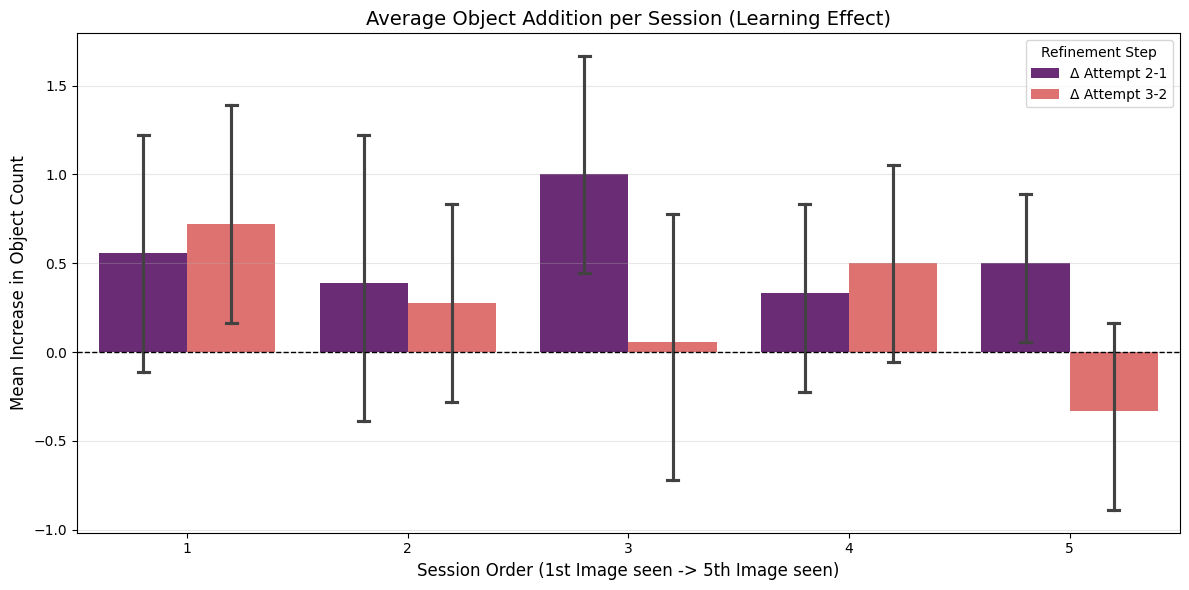

In [52]:
# 5. Create the Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df, 
    x='session', 
    y='Object_Increase', 
    hue='Refinement_Step', 
    palette='magma',
    capsize=.1
)

plt.axhline(0, color='black', lw=1, ls='--') # Baseline
plt.title('Average Object Addition per Session (Learning Effect)', fontsize=14)
plt.xlabel('Session Order (1st Image seen -> 5th Image seen)', fontsize=12)
plt.ylabel('Mean Increase in Object Count', fontsize=12)
plt.legend(title='Refinement Step')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

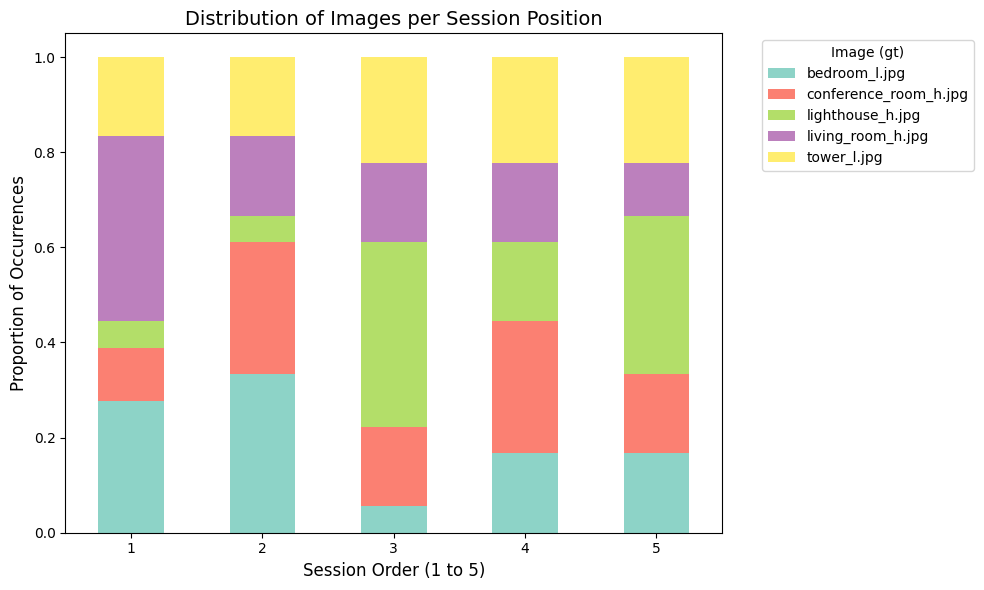

gt       bedroom_l.jpg  conference_room_h.jpg  lighthouse_h.jpg  \
session                                                           
1             0.277778               0.111111          0.055556   
2             0.333333               0.277778          0.055556   
3             0.055556               0.166667          0.388889   
4             0.166667               0.277778          0.166667   
5             0.166667               0.166667          0.333333   

gt       living_room_h.jpg  tower_l.jpg  
session                                  
1                 0.388889     0.166667  
2                 0.166667     0.166667  
3                 0.166667     0.222222  
4                 0.166667     0.222222  
5                 0.111111     0.222222  


In [53]:
# proportions of images in each session:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Count occurrences of each 'gt' in each 'session'
# This creates a table where rows are sessions and columns are images
pivot_table = df.groupby(['session', 'gt']).size().unstack(fill_value=0)

# 2. Convert counts to proportions (normalize by the total counts per row/session)
# This ensures each bar height totals 1.0 (100%)
proportions = pivot_table.div(pivot_table.sum(axis=1), axis=0)

# 3. Create the Stacked Bar Plot
# Using a colormap like 'viridis' or 'Set3' to distinguish the 5 images
ax = proportions.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')

plt.title('Distribution of Images per Session Position', fontsize=14)
plt.xlabel('Session Order (1 to 5)', fontsize=12)
plt.ylabel('Proportion of Occurrences', fontsize=12)
plt.xticks(rotation=0)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Image (gt)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Optional: Print the table to verify the distribution
print(proportions)